<a href="https://colab.research.google.com/github/thiru200600/1M1B-AI-for-Sustainability-Virtual-Internship-/blob/main/aquasense_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AquaSense AI
### Groundwater Depletion Prediction & Water Conservation Advisor
**1M1B AI for Sustainability Virtual Internship** · In collaboration with IBM SkillsBuild & AICTE

**SDG Alignment:** SDG 6 (Clean Water & Sanitation) · SDG 13 (Climate Action) · SDG 11 (Sustainable Cities & Communities)

**Author:** Thiruvikraman S

---

This notebook is a runnable prototype of the AquaSense AI pipeline described in the project deck:

1. **Synthetic block-level dataset** (rainfall, groundwater level, borewell extraction) for sample Tamil Nadu blocks
2. **Depletion prediction model** — trend-based forecasting + CGWB-style risk categorization
3. **RAG knowledge layer** — retrieval over a sample set of water-conservation scheme documents
4. **Advisory generator** — combines prediction + retrieved knowledge into a farmer-facing advisory
5. **Optional interactive demo** using Gradio
6. **Steps to push this repo to GitHub directly from Colab**

> ⚠️ The dataset is **synthetic** (randomly generated for demonstration) and the scheme text is **illustrative**, written to show how the pipeline works. Replace both with real CGWB/state groundwater data and verified official scheme text before using this for actual decisions.


## 0. Setup

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)
plt.rcParams["figure.figsize"] = (9, 4.5)


## 1. Synthetic Dataset

Simulates 12 years of yearly rainfall, groundwater level (metres below ground level — higher = worse),
and borewell extraction index for five sample blocks. Swap this cell for a real CSV
(e.g. from the Central Ground Water Board / State Ground Water Data Centre) when available.


In [3]:
BLOCKS = ["Vembakkam", "Cheyyar", "Polur", "Arani", "Chengam"]
YEARS = list(range(2013, 2025))

rows = []
for block in BLOCKS:
    # Each block gets a random baseline depth and a random depletion trend (m/year)
    base_depth = np.random.uniform(6, 10)
    trend = np.random.uniform(0.15, 0.55)  # metres deeper per year, on average
    for i, year in enumerate(YEARS):
        rainfall_mm = np.random.normal(950, 180)                 # annual rainfall
        extraction_index = np.random.uniform(0.5, 1.0) + i * 0.02  # rises slowly over time
        # Depth increases with trend and extraction, falls back a bit with high rainfall
        depth = base_depth + trend * i - 0.003 * (rainfall_mm - 950) + np.random.normal(0, 0.3)
        rows.append({
            "block": block,
            "year": year,
            "rainfall_mm": round(rainfall_mm, 1),
            "extraction_index": round(extraction_index, 2),
            "groundwater_depth_m": round(max(depth, 1.0), 2),
        })

df = pd.DataFrame(rows)
df.head(10)


,block,year,rainfall_mm,extraction_index,groundwater_depth_m
0,Vembakkam,2013,1066.6,0.58,7.61
1,Vembakkam,2014,1000.2,0.87,8.18
2,Vembakkam,2015,865.5,0.63,8.98
3,Vembakkam,2016,847.2,0.82,9.12
4,Vembakkam,2017,639.5,0.89,10.38
5,Vembakkam,2018,873.0,0.78,10.16
6,Vembakkam,2019,1213.8,0.72,9.82
7,Vembakkam,2020,1410.7,0.66,9.95
8,Vembakkam,2021,742.8,0.69,12.47
9,Vembakkam,2022,842.0,0.73,12.88


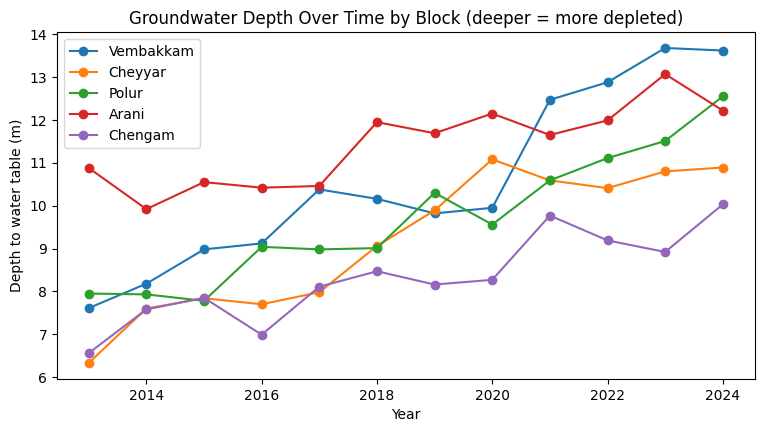

In [4]:
fig, ax = plt.subplots()
for block in BLOCKS:
    sub = df[df.block == block]
    ax.plot(sub.year, sub.groundwater_depth_m, marker="o", label=block)
ax.set_title("Groundwater Depth Over Time by Block (deeper = more depleted)")
ax.set_xlabel("Year")
ax.set_ylabel("Depth to water table (m)")
ax.legend()
plt.show()


## 2. Depletion Prediction Model

A simple linear trend model per block — in a production system this would be a proper
time-series model (e.g. Prophet, ARIMA, or an LSTM) trained on real CGWB well data plus
rainfall and extraction records. The categories below follow the CGWB-style classification
(Safe / Semi-Critical / Critical / Over-Exploited), adapted here to depth-based thresholds
for demonstration.


In [5]:
def fit_block_trend(block_name: str, df: pd.DataFrame):
    sub = df[df.block == block_name].sort_values("year")
    X = sub[["year"]].values
    y = sub["groundwater_depth_m"].values
    model = LinearRegression().fit(X, y)
    return model, sub

def forecast_depth(block_name: str, target_year: int, df: pd.DataFrame):
    model, sub = fit_block_trend(block_name, df)
    pred = model.predict([[target_year]])[0]
    slope = model.coef_[0]  # metres/year -- the depletion rate
    return round(pred, 2), round(slope, 3)

def risk_category(depth_m: float, slope: float) -> str:
    """Illustrative thresholds -- replace with official CGWB block classification."""
    if depth_m < 6 and slope < 0.2:
        return "Safe"
    elif depth_m < 9 and slope < 0.35:
        return "Semi-Critical"
    elif depth_m < 12 and slope < 0.5:
        return "Critical"
    else:
        return "Over-Exploited"

report = []
for block in BLOCKS:
    depth_next, slope = forecast_depth(block, 2026, df)
    risk = risk_category(depth_next, slope)
    report.append({"block": block, "forecast_2026_depth_m": depth_next,
                    "depletion_rate_m_per_yr": slope, "risk_category": risk})

risk_df = pd.DataFrame(report).sort_values("forecast_2026_depth_m", ascending=False)
risk_df


,block,forecast_2026_depth_m,depletion_rate_m_per_yr,risk_category
0,Vembakkam,14.71,0.553,Over-Exploited
3,Arani,13.09,0.224,Over-Exploited
2,Polur,12.76,0.409,Over-Exploited
1,Cheyyar,12.37,0.425,Over-Exploited
4,Chengam,10.26,0.258,Critical


## 3. RAG Knowledge Layer

A minimal retrieval-augmented layer: TF-IDF + cosine similarity over a small set of
scheme documents. In the full product this would embed real, current scheme text
(subsidy amounts, eligibility, application links) fetched from official sources —
here it is a compact illustrative knowledge base so the retrieval logic is runnable
end-to-end without external API keys.


In [6]:
knowledge_base = [
    {
        "id": "drip_irrigation_subsidy",
        "title": "Micro-Irrigation (Drip) Subsidy",
        "text": (
            "Farmers switching to drip or sprinkler irrigation can apply for a subsidy "
            "covering part of the equipment cost. Drip systems typically cut water use for "
            "row crops substantially compared to flood irrigation, easing pressure on borewells."
        ),
        "applies_when": "high extraction_index, semi-critical or critical block",
    },
    {
        "id": "farm_pond_recharge",
        "title": "Farm Pond & Recharge Structure Support",
        "text": (
            "Support is available for building farm ponds and percolation pits that capture "
            "monsoon runoff and recharge the local aquifer, most effective in blocks with "
            "declining water tables and moderate-to-good rainfall."
        ),
        "applies_when": "critical or over-exploited block, moderate+ rainfall",
    },
    {
        "id": "kudimaramathu_water_bodies",
        "title": "Traditional Water Body Restoration (Kudimaramathu-style works)",
        "text": (
            "Community-led desilting and restoration of tanks, ponds, and channels improves "
            "monsoon water retention and indirectly recharges nearby borewells; local "
            "panchayats can nominate water bodies for restoration works."
        ),
        "applies_when": "any block with a traditional tank or water body nearby",
    },
    {
        "id": "borewell_deepening_caution",
        "title": "Guidance: Before Deepening a Borewell",
        "text": (
            "In critical or over-exploited blocks, deepening a failing borewell is discouraged "
            "as a first response, since it accelerates local depletion; conservation and "
            "recharge measures are recommended before any new or deeper drilling."
        ),
        "applies_when": "critical or over-exploited block, farmer asking about digging deeper",
    },
    {
        "id": "crop_water_budgeting",
        "title": "Crop Water Budgeting Advisory",
        "text": (
            "Choosing less water-intensive crops or adjusting the sowing calendar to match "
            "expected rainfall can reduce a farm's total water draw over a season."
        ),
        "applies_when": "any block, general water-saving advice",
    },
]

kb_texts = [f"{d['title']}. {d['text']} {d['applies_when']}" for d in knowledge_base]
vectorizer = TfidfVectorizer(stop_words="english").fit(kb_texts)
kb_matrix = vectorizer.transform(kb_texts)

def retrieve(query: str, top_k: int = 2):
    q_vec = vectorizer.transform([query])
    sims = cosine_similarity(q_vec, kb_matrix).flatten()
    top_idx = sims.argsort()[::-1][:top_k]
    return [(knowledge_base[i], round(float(sims[i]), 3)) for i in top_idx]

# quick check
for doc, score in retrieve("my borewell is giving less water should I dig deeper"):
    print(f"[{score}] {doc['title']}")


[0.462] Guidance: Before Deepening a Borewell
[0.169] Crop Water Budgeting Advisory


## 4. Advisory Generator

Combines the block's risk forecast (step 2) with the retrieved scheme knowledge (step 3)
into a plain-language advisory — the same logic shown in the "Sample Conversation" slide
of the project deck. A production version would route this through an LLM prompt (with the
retrieved text as context) and translate the output into Tamil; here it uses a template so
the notebook runs without any API key.


In [7]:
def generate_advisory(block_name: str, farmer_query: str, df: pd.DataFrame) -> str:
    depth_next, slope = forecast_depth(block_name, 2026, df)
    risk = risk_category(depth_next, slope)
    hits = retrieve(farmer_query, top_k=2)

    lines = []
    lines.append(f"Block: {block_name} | Forecast depth (2026): {depth_next} m | "
                  f"Trend: {slope} m/year deeper | Risk category: {risk}")
    lines.append("")
    if risk in ("Critical", "Over-Exploited"):
        lines.append("Your block shows a serious depletion trend. Digging a new or deeper "
                      "borewell is not recommended as a first step.")
    elif risk == "Semi-Critical":
        lines.append("Your block shows a moderate depletion trend — worth acting on "
                      "proactively before it becomes critical.")
    else:
        lines.append("Your block is currently in the safer range, but conservation habits "
                      "now help keep it that way.")
    lines.append("")
    lines.append("Relevant support you may be eligible for:")
    for doc, score in hits:
        lines.append(f"  • {doc['title']} — {doc['text']}")
    return "\n".join(lines)

print(generate_advisory(
    "Vembakkam",
    "My borewell near Vembakkam gave less water this month. Should I dig deeper or wait for rain?",
    df,
))


Block: Vembakkam | Forecast depth (2026): 14.71 m | Trend: 0.553 m/year deeper | Risk category: Over-Exploited

Your block shows a serious depletion trend. Digging a new or deeper borewell is not recommended as a first step.

Relevant support you may be eligible for:
  • Guidance: Before Deepening a Borewell — In critical or over-exploited blocks, deepening a failing borewell is discouraged as a first response, since it accelerates local depletion; conservation and recharge measures are recommended before any new or deeper drilling.
  • Crop Water Budgeting Advisory — Choosing less water-intensive crops or adjusting the sowing calendar to match expected rainfall can reduce a farm's total water draw over a season.


In [8]:
# Try it with a different block / question
print(generate_advisory(
    "Polur",
    "What can I do to save water on my farm this season?",
    df,
))


Block: Polur | Forecast depth (2026): 12.76 m | Trend: 0.409 m/year deeper | Risk category: Over-Exploited

Your block shows a serious depletion trend. Digging a new or deeper borewell is not recommended as a first step.

Relevant support you may be eligible for:
  • Crop Water Budgeting Advisory — Choosing less water-intensive crops or adjusting the sowing calendar to match expected rainfall can reduce a farm's total water draw over a season.
  • Farm Pond & Recharge Structure Support — Support is available for building farm ponds and percolation pits that capture monsoon runoff and recharge the local aquifer, most effective in blocks with declining water tables and moderate-to-good rainfall.


## 5. Optional: Interactive Demo (Gradio)

Run this cell in Colab for a simple chat-style interface. Skip it if you only need the
notebook logic for your submission.


In [9]:
# !pip install -q gradio
# import gradio as gr
#
# def chat_fn(message, history, block_name):
#     return generate_advisory(block_name, message, df)
#
# demo = gr.ChatInterface(
#     fn=lambda message, history: chat_fn(message, history, "Vembakkam"),
#     title="AquaSense AI — Farmer Advisory Demo",
#     description="Ask about your borewell, block, or water-saving options.",
# )
# demo.launch(debug=True)


## 6. Pushing This Notebook to GitHub from Colab

**Option A — Colab's built-in export (no code required)**
1. In Colab: `File > Save a copy in GitHub`
2. Sign in and authorize Colab to access your GitHub account
3. Pick (or create) the repository and branch, add a commit message, click **OK**

**Option B — Git commands inside a Colab cell**
Run the cell below once, after creating an empty repository on GitHub and generating a
[Personal Access Token](https://github.com/settings/tokens) (classic, with `repo` scope).
Store the token as a Colab secret (key icon in the left sidebar → name it `GITHUB_TOKEN`)
rather than pasting it directly into a cell.


In [10]:
# --- Run this in Colab, not in a plain Jupyter/local kernel ---
# from google.colab import userdata
# GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')
# GITHUB_USERNAME = "your-github-username"
# REPO_NAME = "aquasense-ai"
#
# !git config --global user.email "you@example.com"
# !git config --global user.name "Your Name"
#
# !git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USERNAME}/{REPO_NAME}.git
# %cd {REPO_NAME}
#
# # Save this notebook into the repo folder first (File > Download .ipynb, then upload,
# # or use the Colab file browser to copy it in), then:
# !git add .
# !git commit -m "Add AquaSense AI prototype notebook"
# !git push origin main


---
### Repo structure suggested for submission

```
aquasense-ai/
├── README.md                 # project overview (see below)
├── requirements.txt          # scikit-learn, pandas, numpy, matplotlib
├── aquasense_ai.ipynb         # this notebook
└── AquaSense_AI_Project.pptx  # the project deck
```

Once pushed, add the GitHub repo link to your final project submission alongside the PPT.
